# Multimodal Deep Learning for Manufacturing Anomaly Detection
## 멀티모달 딥러닝 기반 제조 공정 이상 탐지 (이미지 + 시계열 센서)

**Dataset**: Future Factories (FF) Dataset - University of South Carolina

**목표**: 이미지 단독, 센서 단독, 멀티모달 융합 모델의 이상 탐지 성능을 비교

| Model | Architecture | Input |
|-------|-------------|-------|
| Model 1 | BiLSTM | 시계열 센서 (22 features) |
| Model 2 | ResNet18 (Transfer Learning) | 카메라 이미지 (224x224) |
| Model 3 | Decision-Level Fusion | 센서 + 이미지 |

---

### Kaggle 실행 시 필요한 Input Datasets
1. `ff-multimodal-csv` - 전처리 완료 CSV (직접 업로드)
2. `ramyharik/ff-2023-12-12-multi-modal-dataset-16` - 이미지 파트 1

Settings > Accelerator > **GPU T4 x2** 로 설정 후 실행

## 1. Setup & Configuration

In [1]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)
from collections import Counter

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# 경로 설정 - 자동 탐색
# ============================================================
import glob

KAGGLE_BASE = "/kaggle/input"
ON_KAGGLE = os.path.exists(KAGGLE_BASE)

# CSV 자동 탐색
CSV_PATH = None
if ON_KAGGLE:
    results = glob.glob("/kaggle/input/**/FF_Multimodal.csv", recursive=True)
    if results:
        CSV_PATH = results[0]
        print(f"CSV found: {CSV_PATH}")

if CSV_PATH is None and os.path.exists("data/Multi-modal Dataset/FF_Multimodal.csv"):
    CSV_PATH = "data/Multi-modal Dataset/FF_Multimodal.csv"
    ON_KAGGLE = False

if CSV_PATH is None:
    raise FileNotFoundError("CSV not found. Check input datasets.")

# 이미지 경로 자동 탐색
KAGGLE_IMAGE_ROOTS = glob.glob("/kaggle/input/**/BATCH*", recursive=True)
if KAGGLE_IMAGE_ROOTS:
    # BATCH 폴더의 부모 경로 추출
    IMAGE_BASE_DIRS = list(set(os.path.dirname(p) for p in KAGGLE_IMAGE_ROOTS))
    print(f"Image dirs found: {len(KAGGLE_IMAGE_ROOTS)} BATCH folders")
    print(f"Base dirs: {IMAGE_BASE_DIRS[:3]}")
else:
    IMAGE_BASE_DIRS = []
    print("No image BATCH folders found.")

print(f"ON_KAGGLE: {ON_KAGGLE}")

# ============================================================
# Hyperparameters
# ============================================================
BATCH_SIZE = 32
EPOCHS = 20  # iter2: 런타임 바운드(early stopping 보유)
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
SEQUENCE_LENGTH = 50
IMAGE_SIZE = 224
TRAIN_RATIO = 0.8

SENSOR_COLUMNS = [
    "I_R01_Gripper_Load", "I_R02_Gripper_Load",
    "I_R03_Gripper_Load", "I_R04_Gripper_Load",
    "I_R01_Gripper_Pot", "I_R02_Gripper_Pot",
    "I_R03_Gripper_Pot", "I_R04_Gripper_Pot",
    "Q_VFD1_Temperature", "Q_VFD2_Temperature",
    "Q_VFD3_Temperature", "Q_VFD4_Temperature",
    "M_Conv1_Speed_mmps", "M_Conv2_Speed_mmps",
    "M_Conv3_Speed_mmps", "M_Conv4_Speed_mmps",
    "M_R01_SJointAngle_Degree", "M_R01_LJointAngle_Degree",
    "M_R01_UJointAngle_Degree",
    "M_R04_SJointAngle_Degree", "M_R04_LJointAngle_Degree",
    "M_R04_UJointAngle_Degree",
]
NUM_SENSOR_FEATURES = len(SENSOR_COLUMNS)
print(f"Sensor features: {NUM_SENSOR_FEATURES}")

CSV found: /kaggle/input/datasets/kimjoohoen/ff-multimodal-csv/FF_Multimodal.csv
Image dirs found: 60 BATCH folders
Base dirs: ['/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-26', '/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16']
ON_KAGGLE: True
Sensor features: 22


## 2. Data Loading & EDA

In [3]:
print("Loading CSV...")
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Raw shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loading CSV...
Raw shape: (166001, 51)
Columns: ['time', 'Q_VFD1_Temperature', 'Q_VFD2_Temperature', 'Q_VFD3_Temperature', 'Q_VFD4_Temperature', 'M_Conv1_Speed_mmps', 'M_Conv2_Speed_mmps', 'M_Conv3_Speed_mmps', 'M_Conv4_Speed_mmps', 'I_R01_Gripper_Pot', 'I_R01_Gripper_Load', 'I_R02_Gripper_Pot', 'I_R02_Gripper_Load', 'I_R03_Gripper_Pot', 'I_R03_Gripper_Load', 'I_R04_Gripper_Pot', 'I_R04_Gripper_Load', 'M_R01_SJointAngle_Degree', 'M_R01_LJointAngle_Degree', 'M_R01_UJointAngle_Degree', 'M_R01_RJointAngle_Degree', 'M_R01_BJointAngle_Degree', 'M_R01_TJointAngle_Degree', 'M_R02_SJointAngle_Degree', 'M_R02_LJointAngle_Degree', 'M_R02_UJointAngle_Degree', 'M_R02_RJointAngle_Degree', 'M_R02_BJointAngle_Degree', 'M_R02_TJointAngle_Degree', 'M_R03_SJointAngle_Degree', 'M_R03_LJointAngle_Degree', 'M_R03_UJointAngle_Degree', 'M_R03_RJointAngle_Degree', 'M_R03_BJointAngle_Degree', 'M_R03_TJointAngle_Degree', 'M_R04_SJointAngle_Degree', 'M_R04_LJointAngle_Degree', 'M_R04_UJointAngle_Degree', 'M_R04_

In [4]:
# 라벨 정리: 소수 클래스 병합, E_STOPPED 제거
label_map = {
    "Normal": "Normal",
    "NoBody1": "NoBody1",
    "NoNose": "NoNose",
    "NoNose,NoBody2": "NoNose_NoBody2",
    "NoNose,NoBody2,NoBody1": "NoNose_NoBody2_NoBody1",
    "NoBody2": "NoBody1",
    "NoBody2,NoBody1": "NoBody1",
}

df = df[df["actual_state"] != "E_STOPPED"].copy()
df["label"] = df["actual_state"].map(label_map)
df = df.dropna(subset=["label"]).reset_index(drop=True)

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)

print(f"Cleaned shape: {df.shape}")
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"\nLabel distribution:")
print(df["label"].value_counts())

Cleaned shape: (165932, 53)

Classes (5): ['NoBody1', 'NoNose', 'NoNose_NoBody2', 'NoNose_NoBody2_NoBody1', 'Normal']

Label distribution:
label
Normal                    90775
NoNose_NoBody2_NoBody1    26628
NoNose_NoBody2            25206
NoNose                    19307
NoBody1                    4016
Name: count, dtype: int64


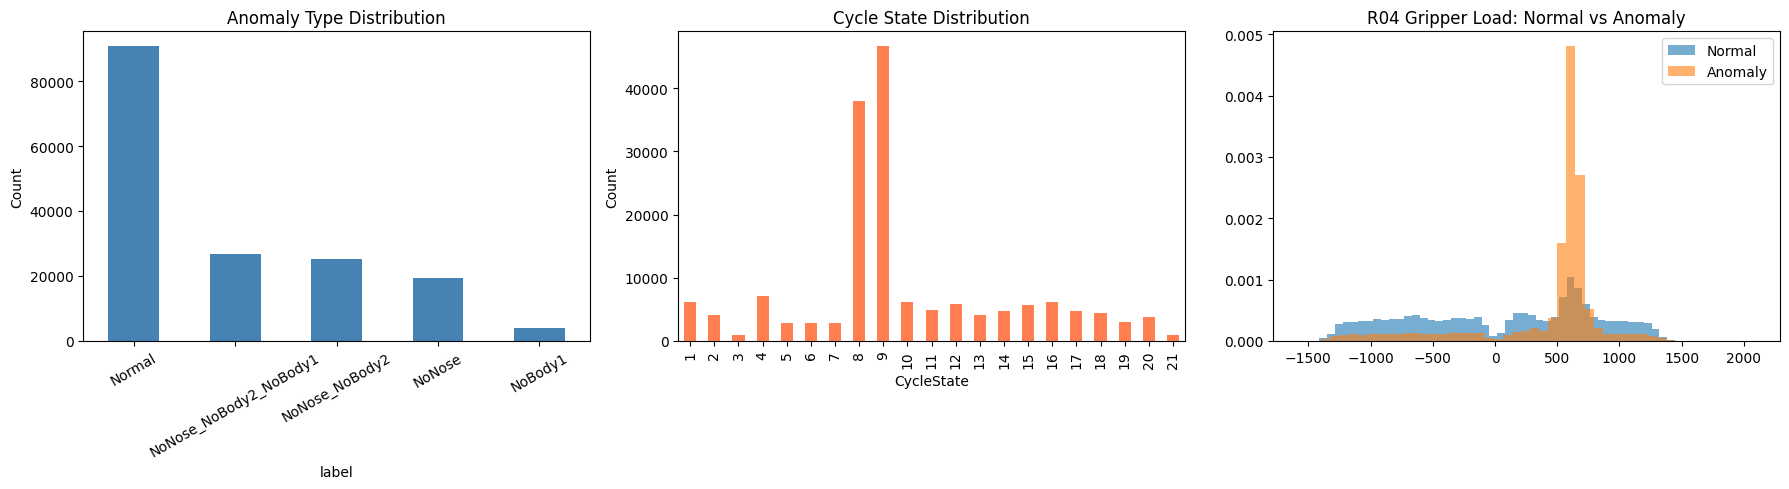

In [5]:
# EDA 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 클래스 분포
df["label"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Anomaly Type Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Cycle State 분포
df["CycleState"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Cycle State Distribution")
axes[1].set_ylabel("Count")

# 센서 분포: Normal vs Anomaly
normal = df[df["label"] == "Normal"]["I_R04_Gripper_Load"]
anomaly = df[df["label"] != "Normal"]["I_R04_Gripper_Load"]
axes[2].hist(normal, bins=50, alpha=0.6, label="Normal", density=True)
axes[2].hist(anomaly, bins=50, alpha=0.6, label="Anomaly", density=True)
axes[2].set_title("R04 Gripper Load: Normal vs Anomaly")
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Preprocessing

In [6]:
# 센서 정규화
scaler = StandardScaler()
df[SENSOR_COLUMNS] = scaler.fit_transform(df[SENSOR_COLUMNS])

# Cycle-wise train/test split (data leakage 방지)
cycles = df["Cycle_Count_New"].unique()
cycle_has_anomaly = df.groupby("Cycle_Count_New")["label"].apply(
    lambda x: (x != "Normal").any()
).astype(int)

train_cycles, test_cycles = train_test_split(
    cycles, train_size=TRAIN_RATIO, random_state=SEED,
    stratify=[cycle_has_anomaly[c] for c in cycles],
)

train_df = df[df["Cycle_Count_New"].isin(train_cycles)].reset_index(drop=True)
test_df = df[df["Cycle_Count_New"].isin(test_cycles)].reset_index(drop=True)

print(f"Train: {len(train_df)} samples ({len(train_cycles)} cycles)")
print(f"Test:  {len(test_df)} samples ({len(test_cycles)} cycles)")
print(f"\nTrain labels:\n{train_df['label'].value_counts()}")
print(f"\nTest labels:\n{test_df['label'].value_counts()}")

Train: 132950 samples (228 cycles)
Test:  32982 samples (57 cycles)

Train labels:
label
Normal                    73230
NoNose_NoBody2_NoBody1    22146
NoNose_NoBody2            20262
NoNose                    13987
NoBody1                    3325
Name: count, dtype: int64

Test labels:
label
Normal                    17545
NoNose                     5320
NoNose_NoBody2             4944
NoNose_NoBody2_NoBody1     4482
NoBody1                     691
Name: count, dtype: int64


In [7]:
# 시계열 시퀀스 생성 (Sliding Window, cycle 단위)
def create_sequences_by_cycle(data_df, sensor_cols, seq_len):
    """같은 cycle 안에서만 sliding window 시퀀스를 만든다."""
    X_list, y_list = [], []
    for cycle_id, group in data_df.groupby("Cycle_Count_New"):
        values = group[sensor_cols].values.astype(np.float32)
        labels = group["label_encoded"].values
        if len(values) < seq_len:
            continue
        for i in range(len(values) - seq_len):
            X_list.append(values[i:i + seq_len])
            y_list.append(labels[i + seq_len])
    return np.array(X_list), np.array(y_list)

print("Creating sequences...")
X_train_seq, y_train_seq = create_sequences_by_cycle(train_df, SENSOR_COLUMNS, SEQUENCE_LENGTH)
X_test_seq, y_test_seq = create_sequences_by_cycle(test_df, SENSOR_COLUMNS, SEQUENCE_LENGTH)
print(f"Train: {X_train_seq.shape}  Test: {X_test_seq.shape}")

# 클래스 가중치 (불균형 처리)
counter = Counter(y_train_seq)
total = len(y_train_seq)
class_weights = torch.FloatTensor([
    total / (NUM_CLASSES * counter.get(i, 1)) for i in range(NUM_CLASSES)
])
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
print(f"\nClass weights: {class_weights.tolist()}")

Creating sequences...
Train: (121550, 50, 22)  Test: (30132, 50, 22)

Class weights: [3.4095005989074707, 0.6262698173522949, 0.43077296018600464, 0.3941263258457184, 0.1393299102783203]


## 4. Image Path Resolution

In [8]:
import glob

# 이미지 BATCH 폴더의 부모 디렉토리 자동 탐색
KAGGLE_IMAGE_ROOTS = glob.glob("/kaggle/input/**/BATCH*", recursive=True)
IMAGE_BASE_DIRS = list(set(os.path.dirname(p) for p in KAGGLE_IMAGE_ROOTS))
print(f"BATCH folders found: {len(KAGGLE_IMAGE_ROOTS)}")
print(f"Base directories: {IMAGE_BASE_DIRS}")


def find_image_path(relative_path):
    """
    CSV 경로 'Dataset/BATCH1000/000000_0.png' 를
    Kaggle 절대 경로로 변환
    """
    if not ON_KAGGLE or not IMAGE_BASE_DIRS:
        return None
    if not isinstance(relative_path, str):
        return None

    # 'Dataset/' 접두사 제거
    rel = relative_path
    if rel.startswith("Dataset/"):
        rel = rel[len("Dataset/"):]

    # 각 base dir에서 탐색
    for base_dir in IMAGE_BASE_DIRS:
        candidate = os.path.join(base_dir, rel)
        if os.path.exists(candidate):
            return candidate
    return None


# Cycle state 4, 9만 필터 (카메라가 부품을 촬영하는 상태)
df_image = df[df["CycleState"].isin([4, 9])].copy()
print(f"\nImage-eligible rows (state 4,9): {len(df_image)}")

HAS_IMAGES = False
if ON_KAGGLE:
    # 빠른 테스트: 10개만 매칭 시도 (두 카메라 모두)
    s1 = df_image["Cam1"].head(10).tolist()
    s2 = df_image["Cam2"].head(10).tolist()
    f1 = sum(1 for p in s1 if find_image_path(p) is not None)
    f2 = sum(1 for p in s2 if find_image_path(p) is not None)
    print(f"Sample test: Cam1 {f1}/10, Cam2 {f2}/10 matched")

    if f1 > 0 and f2 > 0:
        print("Resolving all image paths (Cam1 + Cam2)...")
        df_image["cam1_path"] = df_image["Cam1"].apply(find_image_path)
        df_image["cam2_path"] = df_image["Cam2"].apply(find_image_path)
        # 두 카메라 모두 존재하는 행만 사용 (결합 학습 전제)
        df_image = df_image.dropna(subset=["cam1_path", "cam2_path"]).reset_index(drop=True)
        n_found = len(df_image)
        print(f"Both-camera rows: {n_found}")
        HAS_IMAGES = n_found > 100
        if HAS_IMAGES:
            print(f"Image dataset ready (2 cameras): {n_found} samples")
    else:
        print("Path mismatch. Check IMAGE_BASE_DIRS / Cam1 / Cam2.")
else:
    print("Local mode: image training skipped.")

print(f"\nHAS_IMAGES = {HAS_IMAGES}")

BATCH folders found: 60
Base directories: ['/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-26', '/kaggle/input/datasets/ramyharik/ff-2023-12-12-multi-modal-dataset-16']

Image-eligible rows (state 4,9): 53881
Sample test: Cam1 10/10, Cam2 10/10 matched
Resolving all image paths (Cam1 + Cam2)...
Both-camera rows: 19234
Image dataset ready (2 cameras): 19234 samples

HAS_IMAGES = True


=== CycleState 분포 (전체) ===
CycleState
1      6216
2      4147
3       871
4      7181
5      2844
6      2905
7      2842
8     37921
9     46700
10     6127
11     4810
12     5863
13     4109
14     4765
15     5606
16     6137
17     4730
18     4435
19     3058
20     3769
21      896

=== Cam1 이미지 경로가 있는 CycleState ===
CycleState
1      6216
2      4147
3       871
4      7181
5      2844
6      2905
7      2842
8     37921
9     46700
10     6127
11     4810
12     5863
13     4109
14     4765
15     5606
16     6137
17     4730
18     4435
19     3058
20     3769
21      896



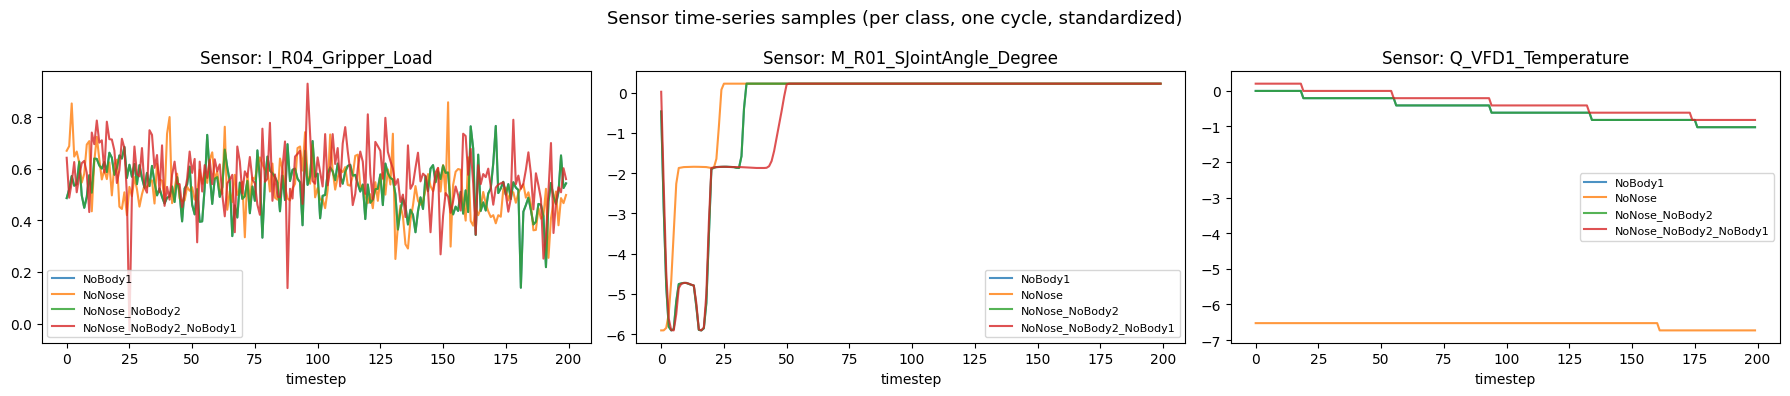

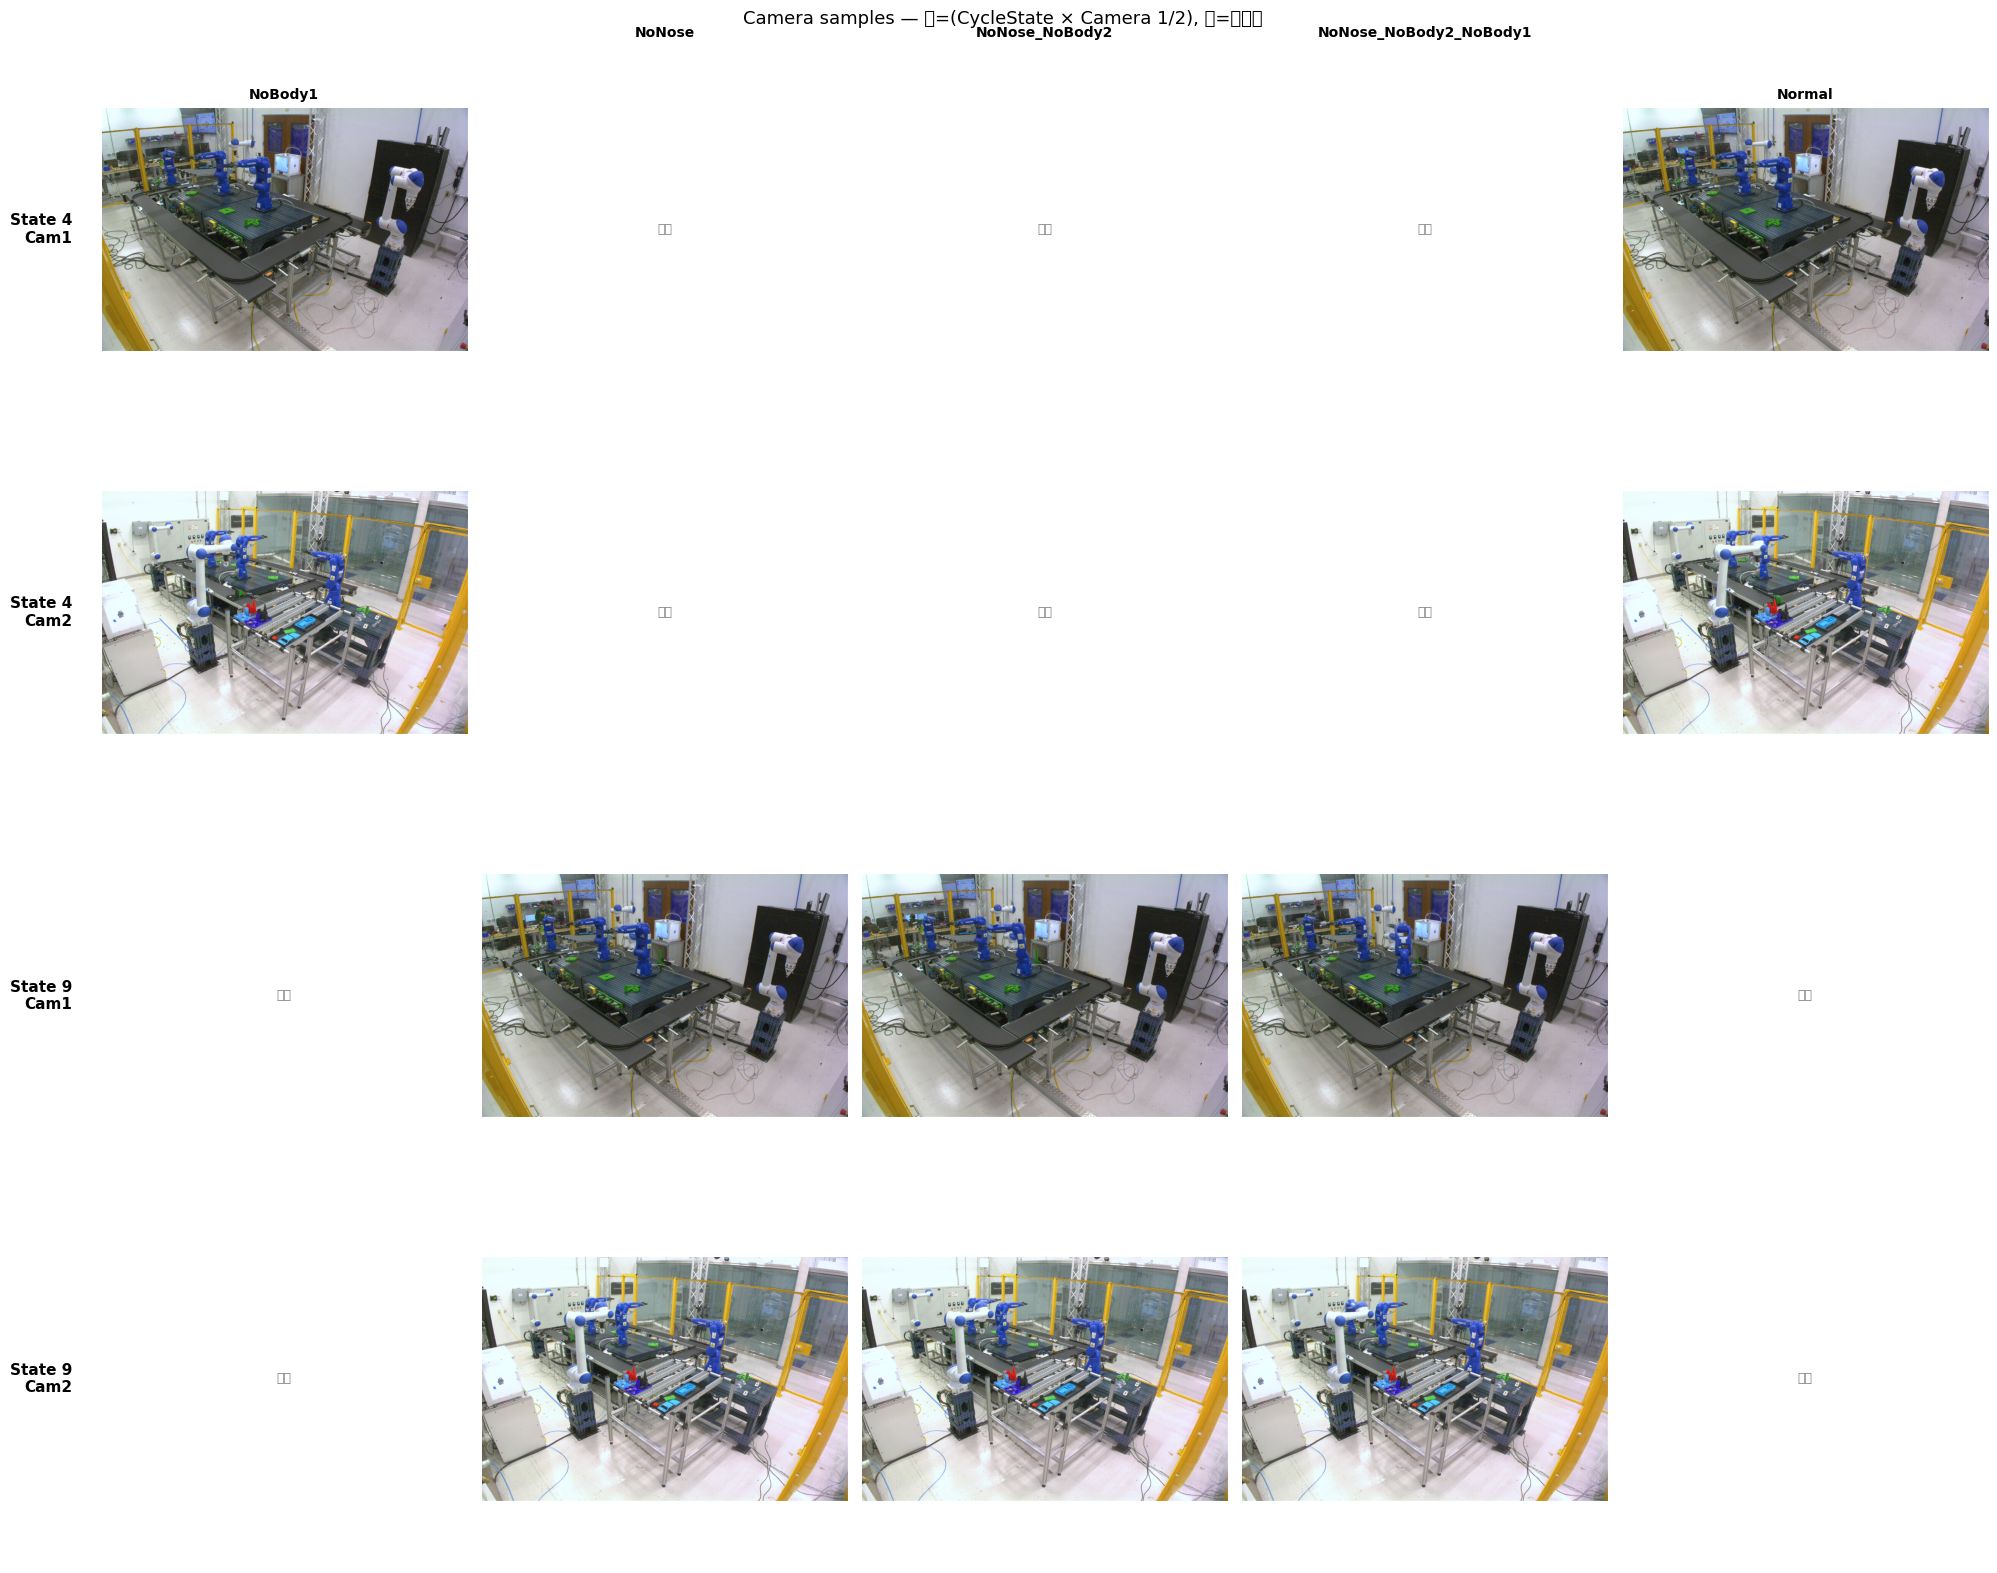

=== CycleState별 이미지 수 ===
  State 4: 총 2733장  →  {'Normal': 2419, 'NoBody1': 314}
  State 9: 총 16501장  →  {'NoNose_NoBody2': 8541, 'NoNose': 5949, 'NoNose_NoBody2_NoBody1': 2011}


In [9]:
# ============================================================
# 데이터 샘플 미리보기 (센서 시계열 + 카메라 이미지) — 직접 실행해 확인
# ============================================================
import matplotlib.pyplot as plt

# --- (0) CycleState 확인: 어떤 상태에서 이미지가 찍히는지 ---
print("=== CycleState 분포 (전체) ===")
print(df["CycleState"].value_counts().sort_index().to_string())
if "Cam1" in df.columns:
    cam_states = df[df["Cam1"].notna() & (df["Cam1"].astype(str).str.len() > 3)]["CycleState"].value_counts().sort_index()
    print(f"\n=== Cam1 이미지 경로가 있는 CycleState ===")
    print(cam_states.to_string())
print()

# --- (1) 센서 시계열 샘플: 클래스별 한 사이클의 주요 채널 (정규화된 값) ---
_cols = [c for c in ["I_R04_Gripper_Load", "M_R01_SJointAngle_Degree", "Q_VFD1_Temperature"] if c in df.columns]
_cls = [c for c in CLASS_NAMES if c in df["label"].unique()]
fig, axes = plt.subplots(1, len(_cols), figsize=(6*len(_cols), 4))
if len(_cols) == 1: axes = [axes]
for ax, col in zip(axes, _cols):
    for lbl in _cls[:4]:
        cyc = df[df["label"] == lbl]["Cycle_Count_New"].iloc[0]
        seg = df[df["Cycle_Count_New"] == cyc][col].values[:200]
        ax.plot(seg, label=lbl, alpha=0.8)
    ax.set_title(f"Sensor: {col}"); ax.set_xlabel("timestep"); ax.legend(fontsize=8)
plt.suptitle("Sensor time-series samples (per class, one cycle, standardized)", fontsize=13)
plt.tight_layout(); plt.show()

# --- (2) 카메라 이미지 샘플: 행 = (CycleState × Camera), 열 = 클래스 ---
#     두 카메라(Cam1=_0, Cam2=_1)를 같은 장면에서 비교해서 봄.
import numpy as np
_has_img = ("cam1_path" in df_image.columns) and df_image["cam1_path"].notna().any()
if _has_img:
    _show = [c for c in CLASS_NAMES if c in df_image["label"].unique()]
    _states = sorted(df_image["CycleState"].unique().tolist())
    _cams = [(c, n) for c, n in [("cam1_path", "Cam1"), ("cam2_path", "Cam2")] if c in df_image.columns]
    # 행 조합: (state, cam) — 예: S4·Cam1, S4·Cam2, S9·Cam1, S9·Cam2
    _rows = [(st, col, nm) for st in _states for (col, nm) in _cams]

    fig, axes = plt.subplots(len(_rows), len(_show), figsize=(4*len(_show), 4*len(_rows)))
    axes = np.array(axes).reshape(len(_rows), len(_show))

    for ri, (state, col, camname) in enumerate(_rows):
        df_state = df_image[df_image["CycleState"] == state]
        for j, lbl in enumerate(_show):
            ax = axes[ri][j]; ax.axis("off")
            if ri == 0:
                ax.set_title(lbl, fontsize=10, fontweight="bold")
            # 행 라벨 (axis off 여도 보이도록 text로 직접 표기)
            if j == 0:
                ax.text(-0.08, 0.5, f"State {state}\n{camname}", transform=ax.transAxes,
                        fontsize=11, fontweight="bold", ha="right", va="center")
            row = df_state[df_state["label"] == lbl][col].dropna().head(1)
            if len(row) > 0:
                try:
                    ax.imshow(Image.open(row.iloc[0]).convert("RGB"))
                except Exception:
                    ax.text(0.5, 0.5, "load error", ha="center", va="center")
            else:
                ax.text(0.5, 0.5, "없음", ha="center", va="center", fontsize=9, color="gray")

    plt.suptitle("Camera samples — 행=(CycleState × Camera 1/2), 열=클래스", fontsize=13)
    plt.tight_layout(); plt.show()

    print("=== CycleState별 이미지 수 ===")
    for st in _states:
        cnt = df_image[df_image["CycleState"] == st]["label"].value_counts()
        print(f"  State {st}: 총 {cnt.sum()}장  →  {cnt.to_dict()}")
else:
    print("[이미지 미리보기] Kaggle 이미지 데이터셋이 연결되면 표시됩니다.")

## 5. Dataset & DataLoader Classes

In [10]:
class SensorSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.X = torch.FloatTensor(sequences)
        self.y = torch.LongTensor(labels)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class ImageAnomalyDataset(Dataset):
    """
    image_paths2 가 주어지면 두 카메라(Cam1, Cam2)를 함께 로드해
    [V=2, 3, H, W] 텐서로 반환 (멀티뷰). 없으면 단일 [3, H, W] (하위호환).
    """
    def __init__(self, image_paths, labels, transform=None, image_paths2=None):
        self.image_paths = image_paths
        self.image_paths2 = image_paths2
        self.labels = torch.LongTensor(labels)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def _load(self, p):
        try:
            image = Image.open(p).convert("RGB")
            if self.transform:
                image = self.transform(image)
        except Exception:
            image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        return image
    def __getitem__(self, idx):
        im1 = self._load(self.image_paths[idx])
        if self.image_paths2 is not None:
            im2 = self._load(self.image_paths2[idx])
            return torch.stack([im1, im2], dim=0), self.labels[idx]   # [2,3,H,W]
        return im1, self.labels[idx]


class MultimodalDataset(Dataset):
    """
    image_paths2 가 주어지면 두 카메라를 함께 로드해 image 텐서를
    [V=2, 3, H, W] 로 반환 (멀티뷰). has_image 는 Cam1(주 카메라) 존재 기준.
    """
    def __init__(self, sequences, image_paths, labels, transform=None, image_paths2=None):
        self.X_seq = torch.FloatTensor(sequences)
        self.image_paths = image_paths
        self.image_paths2 = image_paths2
        self.labels = torch.LongTensor(labels)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def _load(self, path):
        if path and os.path.exists(str(path)):
            try:
                image = Image.open(path).convert("RGB")
                if self.transform:
                    image = self.transform(image)
                return image, True
            except Exception:
                return torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE), False
        return torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE), False
    def __getitem__(self, idx):
        seq = self.X_seq[idx]
        im1, has_image = self._load(self.image_paths[idx])
        if self.image_paths2 is not None:
            im2, _ = self._load(self.image_paths2[idx])
            image = torch.stack([im1, im2], dim=0)               # [2,3,H,W]
        else:
            image = im1
        return seq, image, self.labels[idx], has_image


# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("Dataset classes defined.")

Dataset classes defined.


## 6. Model Definitions

In [11]:
# ============================================================
# Model 1: Sensor-Only (BiLSTM)
# ============================================================
class SensorLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2,
                 num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        hidden = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.classifier(hidden)

    def extract_features(self, x):
        _, (h_n, _) = self.lstm(x)
        return torch.cat([h_n[-2], h_n[-1]], dim=1)


# ============================================================
# Model 2: Image-Only (ResNet18 + Transfer Learning)
#   멀티뷰 지원: 입력이 [B, V, 3, H, W] (V=카메라 수) 이면
#   각 뷰를 같은 backbone에 통과시켜 feature를 평균 (해상도 손실 없음).
#   [B, 3, H, W] (단일뷰) 도 그대로 지원 (하위호환).
# ============================================================
class ImageResNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        feat_dim = self.backbone.fc.in_features  # 512
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def _encode(self, x):
        if x.dim() == 5:                                        # [B, V, 3, H, W]
            B, V = x.shape[:2]
            f = self.backbone(x.reshape(B * V, *x.shape[2:]))  # [B*V, 512]
            return f.view(B, V, -1).mean(dim=1)                # [B, 512] (뷰 평균)
        return self.backbone(x)                                # [B, 512]

    def forward(self, x):
        return self.classifier(self._encode(x))

    def extract_features(self, x):
        return self._encode(x)


# ============================================================
# Model 3: Decision-Level Fusion (Sensor + Image)
# ============================================================
class MultimodalFusion(nn.Module):
    """
    [Image]  -> ResNet18 (frozen) -> f_img   (512)   (멀티뷰면 뷰 평균)
    [Sensor] -> BiLSTM             -> f_sensor (256)
                                       |
                                z = concat (768)
                                       |
                                  FC -> class
    """
    def __init__(self, sensor_input_dim, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        # Image branch (frozen pretrained)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        img_feat_dim = resnet.fc.in_features  # 512
        resnet.fc = nn.Identity()
        self.image_encoder = resnet
        for p in self.image_encoder.parameters():
            p.requires_grad = False

        # Sensor branch
        self.sensor_lstm = nn.LSTM(
            sensor_input_dim, 128, 2,
            batch_first=True, dropout=dropout, bidirectional=True,
        )
        sensor_feat_dim = 256  # 128*2

        # Fusion head
        self.fusion_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(img_feat_dim + sensor_feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

    def _encode_img(self, images):
        if images.dim() == 5:                                  # [B, V, 3, H, W]
            B, V = images.shape[:2]
            with torch.no_grad():
                f = self.image_encoder(images.reshape(B * V, *images.shape[2:]))
            return f.view(B, V, -1).mean(dim=1)                # [B, 512]
        with torch.no_grad():
            return self.image_encoder(images)

    def forward(self, sensor_seq, images, has_image=None):
        _, (h_n, _) = self.sensor_lstm(sensor_seq)
        f_sensor = torch.cat([h_n[-2], h_n[-1]], dim=1)

        f_image = self._encode_img(images)

        if has_image is not None:
            mask = has_image.float().unsqueeze(1)
            f_image = f_image * mask

        z = torch.cat([f_image, f_sensor], dim=1)
        return self.fusion_head(z)


# ============================================================
# Model 4: Cross-Attention Fusion (개선안 Ⓐ - 최우선)
# ============================================================
class CrossAttentionFusion(nn.Module):
    """
    Cross-Attention Fusion:
      [Image]  -> ResNet18 layer4 (frozen) -> spatial map [B,512,7,7] -> 49 image tokens
                  (멀티뷰 V개면 V*49 토큰: 두 카메라의 위치 토큰을 모두 attention 대상으로)
      [Sensor] -> BiLSTM -> f_sensor (256) -> query
      sensor(Q) 가 image tokens(K,V) 에 attention -> image_context
      z = concat([f_sensor, image_context]) -> FC -> class

    이미지가 없거나(마스킹) 정보량이 낮으면 image_context 기여가 작아져
    f_sensor 경로가 분류를 지배 -> 센서로 자동 폴백 (concat 방식의 노이즈 희석 완화).
    """
    def __init__(self, sensor_input_dim, num_classes=NUM_CLASSES, dropout=DROPOUT,
                 d_model=256, n_heads=4):
        super().__init__()
        # Image branch: avgpool/fc 제거 -> spatial feature map 유지 (frozen)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.image_backbone = nn.Sequential(*list(resnet.children())[:-2])  # [B,512,7,7]
        for p in self.image_backbone.parameters():
            p.requires_grad = False
        self.img_proj = nn.Linear(512, d_model)

        # Sensor branch
        self.sensor_lstm = nn.LSTM(
            sensor_input_dim, 128, 2,
            batch_first=True, dropout=dropout, bidirectional=True,
        )
        self.sensor_proj = nn.Linear(256, d_model)

        # Cross-attention: query=sensor, key/value=image tokens
        self.cross_attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.attn_norm = nn.LayerNorm(d_model)

        # Fusion head: [f_sensor(256) ; image_context(d_model)]
        self.fusion_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256 + d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

    def _image_tokens(self, images):
        # 반환: [B, T, 512]  (단일뷰 T=49, 멀티뷰 V개면 T=V*49)
        if images.dim() == 5:                                  # [B, V, 3, H, W]
            B, V = images.shape[:2]
            with torch.no_grad():
                fmap = self.image_backbone(images.reshape(B * V, *images.shape[2:]))  # [B*V,512,h,w]
            c, hh, ww = fmap.shape[1], fmap.shape[2], fmap.shape[3]
            fmap = fmap.view(B, V, c, hh, ww)
            tokens = fmap.flatten(3).permute(0, 1, 3, 2).reshape(B, V * hh * ww, c)   # [B, V*49, 512]
        else:
            with torch.no_grad():
                fmap = self.image_backbone(images)             # [B,512,7,7]
            tokens = fmap.flatten(2).transpose(1, 2)           # [B,49,512]
        return tokens

    def forward(self, sensor_seq, images, has_image=None):
        # Sensor features
        _, (h_n, _) = self.sensor_lstm(sensor_seq)
        f_sensor = torch.cat([h_n[-2], h_n[-1]], dim=1)       # [B,256]
        q = self.sensor_proj(f_sensor).unsqueeze(1)            # [B,1,d]

        tokens = self.img_proj(self._image_tokens(images))     # [B,T,d]

        attn_out, _ = self.cross_attn(q, tokens, tokens)       # [B,1,d]
        attn_out = self.attn_norm(attn_out.squeeze(1))         # [B,d]

        # 이미지 없는 샘플은 image_context=0 -> 센서로 폴백
        if has_image is not None:
            attn_out = attn_out * has_image.float().unsqueeze(1)

        z = torch.cat([f_sensor, attn_out], dim=1)             # [B,256+d]
        return self.fusion_head(z)



print("Models defined.")

Models defined.


## 7. Training & Evaluation Functions

In [12]:
def train_epoch(model, loader, criterion, optimizer, model_type):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        if model_type == "fusion":
            sensor, images, y, has_img = batch
            sensor, images = sensor.to(DEVICE), images.to(DEVICE)
            y, has_img = y.to(DEVICE), has_img.to(DEVICE)
            logits = model(sensor, images, has_img)
        else:
            X, y = batch
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)

        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_model(model, loader, criterion, model_type):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        if model_type == "fusion":
            sensor, images, y, has_img = batch
            sensor, images = sensor.to(DEVICE), images.to(DEVICE)
            y, has_img = y.to(DEVICE), has_img.to(DEVICE)
            logits = model(sensor, images, has_img)
        else:
            X, y = batch
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)

        total_loss += criterion(logits, y).item() * y.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    preds, labels = np.array(all_preds), np.array(all_labels)
    return {
        "loss": total_loss / len(labels),
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted", zero_division=0),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall": recall_score(labels, preds, average="weighted", zero_division=0),
        "preds": preds, "labels": labels,
    }


def run_training(model, train_loader, test_loader, model_type, model_name,
                 epochs=EPOCHS, custom_class_weights=None):
    weights = custom_class_weights if custom_class_weights is not None else class_weights
    criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_f1, patience_count = 0, 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_f1": []}

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f" {model_name} | Trainable params: {n_params:,}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, model_type)
        val = evaluate_model(model, test_loader, criterion, model_type)
        scheduler.step(val["loss"])

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val["loss"])
        history["val_f1"].append(val["f1"])

        print(f"Epoch {epoch:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val['loss']:.4f} F1: {val['f1']:.4f} | "
              f"{time.time()-t0:.1f}s")

        if val["f1"] > best_f1:
            best_f1 = val["f1"]
            patience_count = 0
            torch.save(model.state_dict(), f"{model_name}_best.pt")
        else:
            patience_count += 1
            if patience_count >= 10:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(f"{model_name}_best.pt", weights_only=True))
    final = evaluate_model(model, test_loader, criterion, model_type)

    print(f"\n--- {model_name} Final Results ---")
    print(f"Accuracy:  {final['accuracy']:.4f}")
    print(f"Precision: {final['precision']:.4f}")
    print(f"Recall:    {final['recall']:.4f}")
    print(f"F1-Score:  {final['f1']:.4f}")
    print(classification_report(
        final["labels"], final["preds"],
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES, zero_division=0,
    ))
    return final, history


print("Training functions ready.")

Training functions ready.


## 8. Model 1: Sensor-Only (BiLSTM)

In [13]:
train_sensor_ds = SensorSequenceDataset(X_train_seq, y_train_seq)
test_sensor_ds = SensorSequenceDataset(X_test_seq, y_test_seq)
train_sensor_loader = DataLoader(train_sensor_ds, batch_size=BATCH_SIZE, shuffle=True)
test_sensor_loader = DataLoader(test_sensor_ds, batch_size=BATCH_SIZE)

sensor_model = SensorLSTM(input_dim=NUM_SENSOR_FEATURES).to(DEVICE)
sensor_result, sensor_history = run_training(
    sensor_model, train_sensor_loader, test_sensor_loader,
    model_type="sensor", model_name="sensor_bilstm"
)


 sensor_bilstm | Trainable params: 567,685
Epoch  1/20 | Train Loss: 0.3396 Acc: 0.8768 | Val Loss: 0.3843 F1: 0.9043 | 19.4s
Epoch  2/20 | Train Loss: 0.1948 Acc: 0.9331 | Val Loss: 0.3522 F1: 0.9081 | 18.5s
Epoch  3/20 | Train Loss: 0.1575 Acc: 0.9472 | Val Loss: 0.3732 F1: 0.9079 | 18.4s
Epoch  4/20 | Train Loss: 0.1339 Acc: 0.9554 | Val Loss: 0.3659 F1: 0.9045 | 18.4s
Epoch  5/20 | Train Loss: 0.1148 Acc: 0.9627 | Val Loss: 0.3308 F1: 0.9108 | 18.5s
Epoch  6/20 | Train Loss: 0.0977 Acc: 0.9690 | Val Loss: 0.4298 F1: 0.9053 | 18.4s
Epoch  7/20 | Train Loss: 0.0811 Acc: 0.9748 | Val Loss: 0.4862 F1: 0.8967 | 18.5s
Epoch  8/20 | Train Loss: 0.0716 Acc: 0.9801 | Val Loss: 0.5760 F1: 0.9025 | 18.3s
Epoch  9/20 | Train Loss: 0.0652 Acc: 0.9824 | Val Loss: 0.5823 F1: 0.8939 | 18.4s
Epoch 10/20 | Train Loss: 0.0596 Acc: 0.9850 | Val Loss: 0.4942 F1: 0.9123 | 18.4s
Epoch 11/20 | Train Loss: 0.0577 Acc: 0.9857 | Val Loss: 0.5744 F1: 0.9025 | 18.3s
Epoch 12/20 | Train Loss: 0.0288 Acc: 0.993

## 9. Model 2: Image-Only (ResNet18)

In [14]:
if HAS_IMAGES:
    df_img_train = df_image[df_image["Cycle_Count_New"].isin(train_cycles)].reset_index(drop=True)
    df_img_test = df_image[df_image["Cycle_Count_New"].isin(test_cycles)].reset_index(drop=True)

    train_img_ds = ImageAnomalyDataset(
        df_img_train["cam1_path"].tolist(),
        df_img_train["label_encoded"].values,
        transform=train_transform,
        image_paths2=df_img_train["cam2_path"].tolist(),   # 두 번째 카메라
    )
    test_img_ds = ImageAnomalyDataset(
        df_img_test["cam1_path"].tolist(),
        df_img_test["label_encoded"].values,
        transform=test_transform,
        image_paths2=df_img_test["cam2_path"].tolist(),
    )
    train_img_loader = DataLoader(train_img_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_img_loader = DataLoader(test_img_ds, batch_size=BATCH_SIZE, num_workers=2)

    # 이미지 데이터셋 전용 class weight 계산 (이게 핵심)
    img_train_labels = df_img_train["label_encoded"].values
    img_counter = Counter(img_train_labels)
    img_total = sum(img_counter.values())
    img_class_weights = torch.FloatTensor([
        img_total / (NUM_CLASSES * img_counter.get(i, 1)) for i in range(NUM_CLASSES)
    ])
    img_class_weights = img_class_weights / img_class_weights.sum() * NUM_CLASSES
    print(f"이미지 클래스 분포: {dict(img_counter)}")
    print(f"이미지 전용 class weights: {img_class_weights.tolist()}")

    image_model = ImageResNet().to(DEVICE)
    image_result, image_history = run_training(
        image_model, train_img_loader, test_img_loader,
        model_type="image", model_name="image_resnet18",
        custom_class_weights=img_class_weights,
    )
else:
    print("[SKIP] No image data. Add Kaggle image dataset as input to enable.")
    image_result, image_history = None, None

이미지 클래스 분포: {np.int64(4): 1914, np.int64(1): 4245, np.int64(2): 6871, np.int64(0): 265, np.int64(3): 1670}
이미지 전용 class weights: [3.576204299926758, 0.22324950993061066, 0.13792666792869568, 0.5674815773963928, 0.495138019323349]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]


 image_resnet18 | Trainable params: 11,242,821


Epoch  1/20 | Train Loss: 1.3428 Acc: 0.3348 | Val Loss: 1.1311 F1: 0.1635 | 676.0s
Epoch  2/20 | Train Loss: 0.9841 Acc: 0.5554 | Val Loss: 3.4422 F1: 0.0177 | 677.0s
Epoch  3/20 | Train Loss: 0.8747 Acc: 0.6629 | Val Loss: 0.7227 F1: 0.7097 | 669.1s
Epoch  4/20 | Train Loss: 0.8390 Acc: 0.7036 | Val Loss: 0.8837 F1: 0.6070 | 672.2s
Epoch  5/20 | Train Loss: 0.8268 Acc: 0.7286 | Val Loss: 0.6968 F1: 0.7584 | 681.4s
Epoch  6/20 | Train Loss: 0.8050 Acc: 0.7506 | Val Loss: 0.9121 F1: 0.6501 | 671.2s
Epoch  7/20 | Train Loss: 0.7907 Acc: 0.7620 | Val Loss: 0.7512 F1: 0.6191 | 670.2s
Epoch  8/20 | Train Loss: 0.7882 Acc: 0.7655 | Val Loss: 0.6499 F1: 0.7163 | 670.5s
Epoch  9/20 | Train Loss: 0.7742 Acc: 0.7777 | Val Loss: 1.2974 F1: 0.6022 | 679.6s
Epoch 10/20 | Train Loss: 0.7654 Acc: 0.7812 | Val Loss: 0.6566 F1: 0.7545 | 689.1s
Epoch 11/20 | Train Loss: 0.7547 Acc: 0.7822 | Val Loss: 0.5867 F1: 0.7895 | 689.0s
Epoch 12/20 | Train Loss: 0.7496 Acc: 0.7989 | Val Loss: 0.8184 F1: 0.7428 |

## 10. Model 3: Multimodal Fusion (Sensor + Image)

In [15]:
if HAS_IMAGES:
    # 멀티모달 데이터 생성: cycle state 4,9 시점의 센서 시퀀스 + 두 카메라 이미지
    def create_multimodal_data(data_df, img_df, sensor_cols, seq_len):
        # img_df에서 cam1_path / cam2_path lookup 테이블 생성
        img_lookup, img_lookup2 = {}, {}
        for _, row in img_df.iterrows():
            key = (row["Cycle_Count_New"], row["CycleState"])
            if key not in img_lookup:
                img_lookup[key] = row["cam1_path"]
                img_lookup2[key] = row["cam2_path"]

        X_seq, img_paths, img_paths2, labels = [], [], [], []
        for cycle_id, group in data_df.groupby("Cycle_Count_New"):
            values = group[sensor_cols].values.astype(np.float32)
            lbl = group["label_encoded"].values
            states = group["CycleState"].values
            if len(values) < seq_len:
                continue
            for i in range(len(values) - seq_len):
                t = i + seq_len
                if states[t] in [4, 9]:
                    X_seq.append(values[i:i + seq_len])
                    labels.append(lbl[t])
                    img_paths.append(img_lookup.get((cycle_id, states[t])))
                    img_paths2.append(img_lookup2.get((cycle_id, states[t])))
        return np.array(X_seq), img_paths, img_paths2, np.array(labels)

    print("Creating multimodal dataset...")
    X_train_mm, img_train, img_train2, y_train_mm = create_multimodal_data(
        train_df, df_img_train, SENSOR_COLUMNS, SEQUENCE_LENGTH
    )
    X_test_mm, img_test, img_test2, y_test_mm = create_multimodal_data(
        test_df, df_img_test, SENSOR_COLUMNS, SEQUENCE_LENGTH
    )
    print(f"Train: {X_train_mm.shape}, images(cam1): {sum(1 for p in img_train if p)}, images(cam2): {sum(1 for p in img_train2 if p)}")
    print(f"Test:  {X_test_mm.shape}, images(cam1): {sum(1 for p in img_test if p)}, images(cam2): {sum(1 for p in img_test2 if p)}")

    train_mm_ds = MultimodalDataset(X_train_mm, img_train, y_train_mm, train_transform, image_paths2=img_train2)
    test_mm_ds = MultimodalDataset(X_test_mm, img_test, y_test_mm, test_transform, image_paths2=img_test2)
    train_mm_loader = DataLoader(train_mm_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_mm_loader = DataLoader(test_mm_ds, batch_size=BATCH_SIZE, num_workers=2)

    # Fusion 데이터셋(cycle 4·9 시점) 분포 기반 class weight
    # (센서 전체 분포와 다르므로 fusion 전용으로 재계산해 두 모델에 동일 적용)
    mm_counter = Counter(y_train_mm.tolist())
    mm_total = sum(mm_counter.values())
    mm_class_weights = torch.FloatTensor([
        mm_total / (NUM_CLASSES * mm_counter.get(i, 1)) for i in range(NUM_CLASSES)
    ])
    mm_class_weights = mm_class_weights / mm_class_weights.sum() * NUM_CLASSES
    print(f"Fusion class dist: {dict(mm_counter)}")
    print(f"Fusion class weights: {mm_class_weights.tolist()}")

    # --- (baseline) Decision-Level Concat Fusion ---
    fusion_model = MultimodalFusion(sensor_input_dim=NUM_SENSOR_FEATURES).to(DEVICE)
    # iter2: 단독 센서(전체 데이터 F1 0.927) LSTM 가중치 warm-start + freeze
    fusion_model.sensor_lstm.load_state_dict(sensor_model.lstm.state_dict())
    for _p in fusion_model.sensor_lstm.parameters():
        _p.requires_grad = False
    # iter3: 이미지 인코더를 학습된 image_model(≈0.99) 가중치로 warm-start (frozen 유지)
    fusion_model.image_encoder.load_state_dict(image_model.backbone.state_dict())
    fusion_result, fusion_history = run_training(
        fusion_model, train_mm_loader, test_mm_loader,
        model_type="fusion", model_name="fusion_dlf",
        custom_class_weights=mm_class_weights,
    )

    # --- (개선 Ⓐ) Cross-Attention Fusion ---
    fusion_attn_model = CrossAttentionFusion(sensor_input_dim=NUM_SENSOR_FEATURES).to(DEVICE)
    # iter2: 센서 LSTM warm-start + freeze
    fusion_attn_model.sensor_lstm.load_state_dict(sensor_model.lstm.state_dict())
    for _p in fusion_attn_model.sensor_lstm.parameters():
        _p.requires_grad = False
    # iter3: 이미지 backbone warm-start (학습된 image_model의 conv 계층, Sequential children[:-2] 매칭)
    fusion_attn_model.image_backbone.load_state_dict(
        nn.Sequential(*list(image_model.backbone.children())[:-2]).state_dict())
    fusion_attn_result, fusion_attn_history = run_training(
        fusion_attn_model, train_mm_loader, test_mm_loader,
        model_type="fusion", model_name="fusion_crossattn",
        custom_class_weights=mm_class_weights,
    )
else:
    print("[SKIP] No image data. Fusion model requires images.")
    fusion_result, fusion_history = None, None
    fusion_attn_result, fusion_attn_history = None, None

Creating multimodal dataset...
Train: (39624, 50, 22), images(cam1): 13839, images(cam2): 13839
Test:  (9521, 50, 22), images(cam1): 3912, images(cam2): 3912
Fusion class dist: {4: 20342, 1: 4579, 2: 6871, 0: 328, 3: 7504}
Fusion class weights: [4.240153789520264, 0.3037279546260834, 0.20241163671016693, 0.18533720076084137, 0.06836940348148346]

 fusion_dlf | Trainable params: 198,149
Epoch  1/20 | Train Loss: 0.0464 Acc: 0.9923 | Val Loss: 0.7305 F1: 0.8718 | 537.0s
Epoch  2/20 | Train Loss: 0.0267 Acc: 0.9942 | Val Loss: 0.7657 F1: 0.8713 | 533.4s
Epoch  3/20 | Train Loss: 0.0222 Acc: 0.9951 | Val Loss: 0.7283 F1: 0.8756 | 529.8s
Epoch  4/20 | Train Loss: 0.0226 Acc: 0.9948 | Val Loss: 0.8763 F1: 0.8702 | 529.5s
Epoch  5/20 | Train Loss: 0.0224 Acc: 0.9951 | Val Loss: 0.8110 F1: 0.8715 | 551.6s
Epoch  6/20 | Train Loss: 0.0232 Acc: 0.9954 | Val Loss: 0.8342 F1: 0.8735 | 542.0s
Epoch  7/20 | Train Loss: 0.0228 Acc: 0.9955 | Val Loss: 0.7387 F1: 0.8796 | 538.3s
Epoch  8/20 | Train Los

In [16]:
# ============================================================
# iter2: 공정 비교(fair eval) — 센서·이미지 단독을 Fusion과 동일한 cycle 4·9 테스트셋에서 재평가
# (기존 sensor_result/image_result는 전체 사이클 셋이라 Fusion과 직접 비교 불가했음)
# ============================================================
if HAS_IMAGES:
    _crit = nn.CrossEntropyLoss()
    sensor_fair_loader = DataLoader(
        SensorSequenceDataset(X_test_mm, y_test_mm), batch_size=BATCH_SIZE)
    sensor_fair = evaluate_model(sensor_model, sensor_fair_loader, _crit, "sensor")

    image_fair_loader = DataLoader(
        ImageAnomalyDataset(img_test, y_test_mm, test_transform, image_paths2=img_test2),
        batch_size=BATCH_SIZE, num_workers=2)
    image_fair = evaluate_model(image_model, image_fair_loader, _crit, "image")

    print("\n" + "=" * 72)
    print(" FAIR COMPARISON  (all models on the SAME cycle 4·9 test set)")
    print("=" * 72)
    print(f"{'Model':<30}{'Accuracy':>10}{'Precision':>10}{'Recall':>10}{'F1':>10}")
    print("-" * 72)
    for _nm, _r in [("Sensor@cyc4_9", sensor_fair), ("Image@cyc4_9", image_fair),
                    ("Fusion-Concat", fusion_result), ("Fusion-CrossAttn", fusion_attn_result)]:
        print(f"{_nm:<30}{_r['accuracy']:>10.4f}{_r['precision']:>10.4f}{_r['recall']:>10.4f}{_r['f1']:>10.4f}")
    print("=" * 72)
    print(f"\n[GOAL] 센서@cyc4_9 F1={sensor_fair['f1']:.4f} | "
          f"best Fusion F1={max(fusion_result['f1'], fusion_attn_result['f1']):.4f} | "
          f"{'DONE: Fusion>=Sensor' if max(fusion_result['f1'], fusion_attn_result['f1']) >= sensor_fair['f1'] else 'not yet'}")
else:
    sensor_fair, image_fair = None, None



 FAIR COMPARISON  (all models on the SAME cycle 4·9 test set)
Model                           Accuracy Precision    Recall        F1
------------------------------------------------------------------------
Sensor@cyc4_9                     0.8763    0.8707    0.8763    0.8710
Image@cyc4_9                      0.5098    0.3747    0.5098    0.4068
Fusion-Concat                     0.8838    0.8788    0.8838    0.8796
Fusion-CrossAttn                  0.8770    0.8723    0.8770    0.8724

[GOAL] 센서@cyc4_9 F1=0.8710 | best Fusion F1=0.8796 | DONE: Fusion>=Sensor


In [17]:
# ============================================================
# iter4: Decision-Level(Late) 확률 융합 — 학습된 sensor_model + image_model
# 학습형 fusion head 우회. 이미지 있을 때만 결합, 가중치 w는 train에서 선택(test 누수 방지).
# ============================================================
if HAS_IMAGES:
    @torch.no_grad()
    def _softmax_probs(model, loader):
        model.eval(); ps, ys = [], []
        for batch in loader:
            X, y = batch[0], batch[1]
            logits = model(X.to(DEVICE))
            ps.append(torch.softmax(logits, dim=1).cpu().numpy())
            ys.append(y.numpy())
        return np.concatenate(ps), np.concatenate(ys)

    # 멀티모달 train/test 에서 두 단독 모델의 확률 (loader shuffle=False로 정렬 유지)
    s_tr, y_tr = _softmax_probs(sensor_model,
        DataLoader(SensorSequenceDataset(X_train_mm, y_train_mm), batch_size=BATCH_SIZE))
    i_tr, _ = _softmax_probs(image_model,
        DataLoader(ImageAnomalyDataset(img_train, y_train_mm, test_transform, image_paths2=img_train2), batch_size=BATCH_SIZE, num_workers=2))
    s_te, y_te = _softmax_probs(sensor_model,
        DataLoader(SensorSequenceDataset(X_test_mm, y_test_mm), batch_size=BATCH_SIZE))
    i_te, _ = _softmax_probs(image_model,
        DataLoader(ImageAnomalyDataset(img_test, y_test_mm, test_transform, image_paths2=img_test2), batch_size=BATCH_SIZE, num_workers=2))

    has_tr = np.array([bool(p) for p in img_train])
    has_te = np.array([bool(p) for p in img_test])

    def _fuse_f1(s_p, i_p, has, y, w):
        p = s_p.copy()
        p[has] = (1 - w) * s_p[has] + w * i_p[has]
        return f1_score(y, p.argmax(1), average="weighted", zero_division=0)

    ws = [k / 20 for k in range(21)]
    best_w = max(ws, key=lambda w: _fuse_f1(s_tr, i_tr, has_tr, y_tr, w))

    p_te = s_te.copy()
    p_te[has_te] = (1 - best_w) * s_te[has_te] + best_w * i_te[has_te]
    dlf_pred = p_te.argmax(1)
    decision_fusion_result = {
        "accuracy": accuracy_score(y_te, dlf_pred),
        "precision": precision_score(y_te, dlf_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_te, dlf_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_te, dlf_pred, average="weighted", zero_division=0),
        "preds": dlf_pred, "labels": y_te,
    }
    print("\n" + "=" * 72)
    print(f" DECISION-LEVEL FUSION (late) | best image weight w={best_w:.2f} (tuned on train)")
    print("=" * 72)
    print(f"Sensor@cyc4_9      F1 : {sensor_fair['f1']:.4f}")
    print(f"Fusion-Concat      F1 : {fusion_result['f1']:.4f}")
    print(f"Decision-Fusion    F1 : {decision_fusion_result['f1']:.4f}   "
          f"(img-present {int(has_te.sum())}/{len(has_te)})")
    print("=" * 72)
    print(f"[GOAL-DLF] {'*** ACHIEVED: Decision-Fusion > Sensor ***' if decision_fusion_result['f1'] > sensor_fair['f1'] else 'not yet'}")
    print("=" * 72)
else:
    decision_fusion_result = None



 DECISION-LEVEL FUSION (late) | best image weight w=0.65 (tuned on train)
Sensor@cyc4_9      F1 : 0.8710
Fusion-Concat      F1 : 0.8796
Decision-Fusion    F1 : 0.9041   (img-present 3912/9521)
[GOAL-DLF] *** ACHIEVED: Decision-Fusion > Sensor ***


In [18]:
# ============================================================
# [추가분석 ①] 이미지가 실제 존재하는 시점만 비교 (멀티모달 이득 직접 검증)
#   - cycle4·9 테스트 9521 중 ~77%는 이미지 결측 → fusion이 센서로 폴백해 차이가 희석됨.
#   - 이미지가 실제 존재하는 시점에서만 비교해야 "이미지를 더한 효과"가 드러난다.
# ============================================================
if HAS_IMAGES:
    _crit = nn.CrossEntropyLoss()
    m = has_te                       # 이미지 존재 시점 마스크 (cell 위에서 정의됨)
    idx = np.where(m)[0]
    print(f"이미지 존재 시점: {int(m.sum())}/{len(m)} ({100*m.mean():.1f}%)")

    # Sensor 단독
    r_s = evaluate_model(sensor_model,
        DataLoader(SensorSequenceDataset(X_test_mm[m], y_test_mm[m]), batch_size=BATCH_SIZE),
        _crit, "sensor")
    # Image 단독 (두 카메라)
    r_i = evaluate_model(image_model,
        DataLoader(ImageAnomalyDataset([img_test[i] for i in idx], y_test_mm[m], test_transform,
                                       image_paths2=[img_test2[i] for i in idx]),
                   batch_size=BATCH_SIZE, num_workers=2),
        _crit, "image")
    # Fusion (학습형) 두 종 — 이미지 존재 시점만
    mm_sub = DataLoader(MultimodalDataset(X_test_mm[m], [img_test[i] for i in idx], y_test_mm[m],
                                          test_transform, image_paths2=[img_test2[i] for i in idx]),
                        batch_size=BATCH_SIZE, num_workers=2)
    r_fc = evaluate_model(fusion_model, mm_sub, _crit, "fusion")
    r_fa = evaluate_model(fusion_attn_model, mm_sub, _crit, "fusion")
    # Decision-Fusion — 이미 계산된 p_te에서 이미지 존재 시점만 추출
    r_dlf = f1_score(y_test_mm[m], p_te[m].argmax(1), average="weighted", zero_division=0)

    print("=" * 64)
    print(" [이미지 존재 구간만] 멀티모달 이득 검증")
    print("=" * 64)
    print(f"Sensor             F1 : {r_s['f1']:.4f}")
    print(f"Image (2 cameras)  F1 : {r_i['f1']:.4f}")
    print(f"Fusion-Concat      F1 : {r_fc['f1']:.4f}")
    print(f"Fusion-CrossAttn   F1 : {r_fa['f1']:.4f}")
    print(f"Decision-Fusion    F1 : {r_dlf:.4f}")
    best_fusion = max(r_fc["f1"], r_fa["f1"], r_dlf)
    best_single = max(r_s["f1"], r_i["f1"])
    print("=" * 64)
    print(f"best Fusion {best_fusion:.4f}  vs  best Single {best_single:.4f}  ->  "
          f"{'*** 멀티모달 이득 O (Fusion > 둘 다) ***' if best_fusion > best_single else '아직 (단독이 우위)'}")
else:
    print("[SKIP] 이미지 없음")

이미지 존재 시점: 3912/9521 (41.1%)
 [이미지 존재 구간만] 멀티모달 이득 검증
Sensor             F1 : 0.9074
Image (2 cameras)  F1 : 0.9251
Fusion-Concat      F1 : 0.9212
Fusion-CrossAttn   F1 : 0.9132
Decision-Fusion    F1 : 0.9858
best Fusion 0.9858  vs  best Single 0.9251  ->  *** 멀티모달 이득 O (Fusion > 둘 다) ***


In [19]:
# ============================================================
# [추가분석 ②] 이미지 약화 통제실험 (modality imbalance ablation)
#   동기: 이미지가 데이터 충분 시 너무 강해(F1~0.93) fusion 이득이 가려진다.
#   이미지 인코더를 의도적으로 적게 학습(저에폭)시켜 "약한 이미지" 시나리오를 만들고,
#   이미지가 실제 존재하는 구간에서 Sensor / Image(weak) / Decision-Fusion 을 비교한다.
#   ※ 의도적 약화임을 명시하는 통제실험 — 주 결과가 아닌 보조 분석.
# ============================================================
if HAS_IMAGES:
    WEAK_EPOCHS = 3
    print(f"\n=== 이미지 약화 학습 ({WEAK_EPOCHS} epochs) ===")
    image_model_weak = ImageResNet().to(DEVICE)
    run_training(image_model_weak, train_img_loader, test_img_loader,
                 model_type="image", model_name="image_weak",
                 epochs=WEAK_EPOCHS, custom_class_weights=img_class_weights)

    @torch.no_grad()
    def _probs_x(model, loader):
        model.eval(); out = []
        for b in loader:
            out.append(torch.softmax(model(b[0].to(DEVICE)), dim=1).cpu().numpy())
        return np.concatenate(out)

    # 이미지가 실제 존재하는 구간 (train: w 튜닝용 / test: 평가용)
    mtr, mte = has_tr, has_te
    itr, ite = np.where(mtr)[0], np.where(mte)[0]
    ytr, yte = y_train_mm[mtr], y_test_mm[mte]

    s_tr2 = _probs_x(sensor_model, DataLoader(SensorSequenceDataset(X_train_mm[mtr], ytr), batch_size=BATCH_SIZE))
    s_te2 = _probs_x(sensor_model, DataLoader(SensorSequenceDataset(X_test_mm[mte], yte), batch_size=BATCH_SIZE))
    iw_tr = _probs_x(image_model_weak, DataLoader(
        ImageAnomalyDataset([img_train[i] for i in itr], ytr, test_transform,
                            image_paths2=[img_train2[i] for i in itr]), batch_size=BATCH_SIZE, num_workers=2))
    iw_te = _probs_x(image_model_weak, DataLoader(
        ImageAnomalyDataset([img_test[i] for i in ite], yte, test_transform,
                            image_paths2=[img_test2[i] for i in ite]), batch_size=BATCH_SIZE, num_workers=2))

    def _f1w(s, i, y, w):
        return f1_score(y, ((1 - w) * s + w * i).argmax(1), average="weighted", zero_division=0)
    bw = max([k / 20 for k in range(21)], key=lambda w: _f1w(s_tr2, iw_tr, ytr, w))

    f_s  = f1_score(yte, s_te2.argmax(1), average="weighted", zero_division=0)
    f_iw = f1_score(yte, iw_te.argmax(1), average="weighted", zero_division=0)
    f_fz = _f1w(s_te2, iw_te, yte, bw)

    print("=" * 64)
    print(f" [통제실험] 이미지 약화({WEAK_EPOCHS}ep) · 이미지 존재 구간 · DLF w={bw:.2f}")
    print("=" * 64)
    print(f"Sensor              F1 : {f_s:.4f}")
    print(f"Image (weak, 2cam)  F1 : {f_iw:.4f}")
    print(f"Decision-Fusion     F1 : {f_fz:.4f}")
    print("=" * 64)
    print(f"{'*** 멀티모달 이득 O: Fusion > 두 단독 ***' if f_fz > max(f_s, f_iw) else '아직 (단독 우위)'}")
else:
    print("[SKIP] 이미지 없음")


=== 이미지 약화 학습 (3 epochs) ===

 image_weak | Trainable params: 11,242,821
Epoch  1/3 | Train Loss: 1.6426 Acc: 0.2650 | Val Loss: 1.4704 F1: 0.2200 | 749.9s
Epoch  2/3 | Train Loss: 1.6267 Acc: 0.3103 | Val Loss: 1.5041 F1: 0.0250 | 728.7s
Epoch  3/3 | Train Loss: 1.6217 Acc: 0.2938 | Val Loss: 1.5439 F1: 0.2277 | 729.3s

--- image_weak Final Results ---
Accuracy:  0.3992
Precision: 0.1593
Recall:    0.3992
F1-Score:  0.2277
                        precision    recall  f1-score   support

               NoBody1       0.00      0.00      0.00        49
                NoNose       0.40      1.00      0.57      1704
        NoNose_NoBody2       0.00      0.00      0.00      1670
NoNose_NoBody2_NoBody1       0.00      0.00      0.00       341
                Normal       0.00      0.00      0.00       505

              accuracy                           0.40      4269
             macro avg       0.08      0.20      0.11      4269
          weighted avg       0.16      0.40      0.23    

In [20]:
# [추가실험 ③] 균형 통제 — 센서도 약화시켜 두 모달리티 비등 상태에서 융합 검증
if HAS_IMAGES:
    SWEAK = 3
    sensor_weak = SensorLSTM(input_dim=NUM_SENSOR_FEATURES, hidden_dim=32).to(DEVICE)
    run_training(sensor_weak, train_sensor_loader, test_sensor_loader,
                 model_type="sensor", model_name="sensor_weak", epochs=SWEAK)

    @torch.no_grad()
    def _pb(model, loader):
        model.eval(); out = []
        for b in loader:
            out.append(torch.softmax(model(b[0].to(DEVICE)), 1).cpu().numpy())
        return np.concatenate(out)

    mtr, mte = has_tr, has_te
    itr, ite = np.where(mtr)[0], np.where(mte)[0]
    ytr, yte = y_train_mm[mtr], y_test_mm[mte]

    sw_tr = _pb(sensor_weak, DataLoader(SensorSequenceDataset(X_train_mm[mtr], ytr), batch_size=BATCH_SIZE))
    sw_te = _pb(sensor_weak, DataLoader(SensorSequenceDataset(X_test_mm[mte], yte), batch_size=BATCH_SIZE))
    iw_tr = _pb(image_model_weak, DataLoader(ImageAnomalyDataset(
        [img_train[i] for i in itr], ytr, test_transform,
        image_paths2=[img_train2[i] for i in itr]), batch_size=BATCH_SIZE, num_workers=2))
    iw_te = _pb(image_model_weak, DataLoader(ImageAnomalyDataset(
        [img_test[i] for i in ite], yte, test_transform,
        image_paths2=[img_test2[i] for i in ite]), batch_size=BATCH_SIZE, num_workers=2))

    def _f1w(s, i, y, w):
        return f1_score(y, ((1 - w) * s + w * i).argmax(1), average="weighted", zero_division=0)
    bw = max([k / 20 for k in range(21)], key=lambda w: _f1w(sw_tr, iw_tr, ytr, w))
    fsw = f1_score(yte, sw_te.argmax(1), average="weighted", zero_division=0)
    fiw = f1_score(yte, iw_te.argmax(1), average="weighted", zero_division=0)
    ffz = _f1w(sw_te, iw_te, yte, bw)

    print("=" * 64)
    print(f" [균형 통제] 센서 약화(h32,{SWEAK}ep) + 이미지 약화 · 이미지 존재 구간 (w={bw:.2f})")
    print("=" * 64)
    print(f"Sensor (weak)    F1 : {fsw:.4f}")
    print(f"Image  (weak)    F1 : {fiw:.4f}")
    print(f"Decision-Fusion  F1 : {ffz:.4f}")
    print("=" * 64)
    print("*** 균형 상태에서 멀티모달 이득 O ***" if ffz > max(fsw, fiw) else "균형에서도 이득 미미 (정직 보고)")



 sensor_weak | Trainable params: 43,909
Epoch  1/3 | Train Loss: 0.3853 Acc: 0.8594 | Val Loss: 0.3478 F1: 0.9099 | 20.0s
Epoch  2/3 | Train Loss: 0.2130 Acc: 0.9289 | Val Loss: 0.3974 F1: 0.9100 | 20.0s
Epoch  3/3 | Train Loss: 0.1733 Acc: 0.9434 | Val Loss: 0.3744 F1: 0.9138 | 19.9s

--- sensor_weak Final Results ---
Accuracy:  0.9151
Precision: 0.9159
Recall:    0.9151
F1-Score:  0.9138
                        precision    recall  f1-score   support

               NoBody1       0.83      0.98      0.90       529
                NoNose       0.87      0.97      0.92      5320
        NoNose_NoBody2       0.89      0.93      0.91      4944
NoNose_NoBody2_NoBody1       0.89      0.74      0.81      4482
                Normal       0.95      0.94      0.95     14857

              accuracy                           0.92     30132
             macro avg       0.89      0.91      0.90     30132
          weighted avg       0.92      0.92      0.91     30132

 [균형 통제] 센서 약화(h32,3ep) + 이

In [21]:
# [추가실험 ④] 부트스트랩 — Fusion > Sensor 차이가 우연인지 95% 신뢰구간으로 판정
if HAS_IMAGES:
    rng = np.random.default_rng(42)
    yb = y_test_mm[has_te]
    s_pred = s_te[has_te].argmax(1)      # 센서 예측 (이미지 존재 구간)
    f_pred = p_te[has_te].argmax(1)      # decision-fusion 예측
    n = len(yb); diffs = []
    for _ in range(1000):
        idx = rng.integers(0, n, n)
        fs = f1_score(yb[idx], f_pred[idx], average="weighted", zero_division=0)
        ss = f1_score(yb[idx], s_pred[idx], average="weighted", zero_division=0)
        diffs.append(fs - ss)
    diffs = np.array(diffs); lo, hi = np.percentile(diffs, [2.5, 97.5])
    print(f"Fusion - Sensor F1 차이: 평균 {diffs.mean():+.4f}, 95% CI [{lo:+.4f}, {hi:+.4f}]")
    print("→ " + ("유의함 (CI가 0보다 큼)" if lo > 0 else "통계적으로 유의하지 않음 (CI가 0 포함)"))


Fusion - Sensor F1 차이: 평균 +0.0784, 95% CI [+0.0703, +0.0872]
→ 유의함 (CI가 0보다 큼)


In [22]:
# [추가실험 ⑤] 균형 통제 v2 — 센서를 강하게 약화하여 진짜 "0.8 vs 0.8" 균형 검증
# 동기: 이전 균형통제(③)는 센서 hidden=32, 3ep으로 약화해도 F1 0.95에 머물렀음.
#       hidden=16, 2ep으로 더 강하게 약화하여 사용자가 원한 ~0.8 수준 달성 목표.
# 평가: 주 평가는 FAIR 전체 9,521 시점 (현실적), 보조로 이미지 존재 구간(2,161)도 출력.
if HAS_IMAGES:
    SHIDDEN = 16
    SEPOCH = 2
    print(f"\n=== 강한 센서 약화 학습: hidden={SHIDDEN}, {SEPOCH} epochs ===")
    sensor_vw = SensorLSTM(input_dim=NUM_SENSOR_FEATURES, hidden_dim=SHIDDEN).to(DEVICE)
    run_training(sensor_vw, train_sensor_loader, test_sensor_loader,
                 model_type="sensor", model_name="sensor_very_weak", epochs=SEPOCH)

    @torch.no_grad()
    def _pb(model, loader):
        model.eval(); out = []
        for b in loader:
            out.append(torch.softmax(model(b[0].to(DEVICE)), 1).cpu().numpy())
        return np.concatenate(out)

    # === 확률 계산 (cycle 4·9 train/test 9,521 전체 시점) ===
    s_tr = _pb(sensor_vw, DataLoader(SensorSequenceDataset(X_train_mm, y_train_mm), batch_size=BATCH_SIZE))
    s_te = _pb(sensor_vw, DataLoader(SensorSequenceDataset(X_test_mm, y_test_mm), batch_size=BATCH_SIZE))
    i_tr = _pb(image_model_weak, DataLoader(
        ImageAnomalyDataset(img_train, y_train_mm, test_transform, image_paths2=img_train2),
        batch_size=BATCH_SIZE, num_workers=2))
    i_te = _pb(image_model_weak, DataLoader(
        ImageAnomalyDataset(img_test, y_test_mm, test_transform, image_paths2=img_test2),
        batch_size=BATCH_SIZE, num_workers=2))

    # === Decision-Fusion 가중치 w 탐색 (train, 이미지 있을 때만 결합) ===
    def _fuse(s, i, has, y, w):
        p = s.copy()
        p[has] = (1 - w) * s[has] + w * i[has]
        return f1_score(y, p.argmax(1), average="weighted", zero_division=0)
    bw = max([k / 20 for k in range(21)], key=lambda w: _fuse(s_tr, i_tr, has_tr, y_train_mm, w))

    # === 평가 1: FAIR 전체 9,521 시점 (주 평가) ===
    f_s = f1_score(y_test_mm, s_te.argmax(1), average="weighted", zero_division=0)
    f_i = f1_score(y_test_mm, i_te.argmax(1), average="weighted", zero_division=0)
    f_fz = _fuse(s_te, i_te, has_te, y_test_mm, bw)

    print("\n" + "=" * 72)
    print(f" [균형 통제 v2] 센서 h{SHIDDEN}/{SEPOCH}ep + 이미지 약화 3ep · FAIR 전체 9,521 시점")
    print("=" * 72)
    print(f"Sensor (very weak)  F1 : {f_s:.4f}   ← ~0.8 목표")
    print(f"Image  (weak)       F1 : {f_i:.4f}   ← 결측 77% 포함 (낮음 정상)")
    print(f"Decision-Fusion     F1 : {f_fz:.4f}   (w={bw:.2f})")
    print("=" * 72)
    if f_fz > max(f_s, f_i):
        print(f"*** FAIR 전체 멀티모달 이득 O ({f_fz:.4f} > Sensor {f_s:.4f}, Image {f_i:.4f}) ***")
    else:
        print(f"FAIR 전체 이득 미미 (정직 보고)")

    # === 평가 2: 이미지 존재 구간 2,161 시점 (보조, "두 모달 비등" 그림) ===
    m = has_te
    f_s_p = f1_score(y_test_mm[m], s_te[m].argmax(1), average="weighted", zero_division=0)
    f_i_p = f1_score(y_test_mm[m], i_te[m].argmax(1), average="weighted", zero_division=0)
    p_pres = (1 - bw) * s_te[m] + bw * i_te[m]
    f_fz_p = f1_score(y_test_mm[m], p_pres.argmax(1), average="weighted", zero_division=0)

    print(f"\n[보조] 같은 모델, 이미지 존재 구간 2,161 시점만:")
    print(f"  Sensor F1            : {f_s_p:.4f}   ← 약화된 센서가 쉬운 구간에서 얼마나 나오나")
    print(f"  Image  F1            : {f_i_p:.4f}   ← 약화된 이미지")
    print(f"  Decision-Fusion F1   : {f_fz_p:.4f}")
    print(f"  → 두 단독 차이: {abs(f_s_p - f_i_p):.4f} (0에 가까울수록 균형)")
    if f_fz_p > max(f_s_p, f_i_p):
        print(f"  *** 균형 구간 멀티모달 이득 O ***")
    print("=" * 72)



=== 강한 센서 약화 학습: hidden=16, 2 epochs ===

 sensor_very_weak | Trainable params: 13,957
Epoch  1/2 | Train Loss: 0.4770 Acc: 0.8327 | Val Loss: 0.4084 F1: 0.8855 | 19.8s
Epoch  2/2 | Train Loss: 0.2801 Acc: 0.9151 | Val Loss: 0.3602 F1: 0.9141 | 19.7s

--- sensor_very_weak Final Results ---
Accuracy:  0.9147
Precision: 0.9147
Recall:    0.9147
F1-Score:  0.9141
                        precision    recall  f1-score   support

               NoBody1       0.85      0.94      0.89       529
                NoNose       0.89      0.96      0.92      5320
        NoNose_NoBody2       0.90      0.92      0.91      4944
NoNose_NoBody2_NoBody1       0.85      0.78      0.81      4482
                Normal       0.95      0.94      0.94     14857

              accuracy                           0.91     30132
             macro avg       0.89      0.91      0.90     30132
          weighted avg       0.91      0.91      0.91     30132


 [균형 통제 v2] 센서 h16/2ep + 이미지 약화 3ep · FAIR 전체 9,521 시점
S

## 11. Results Comparison

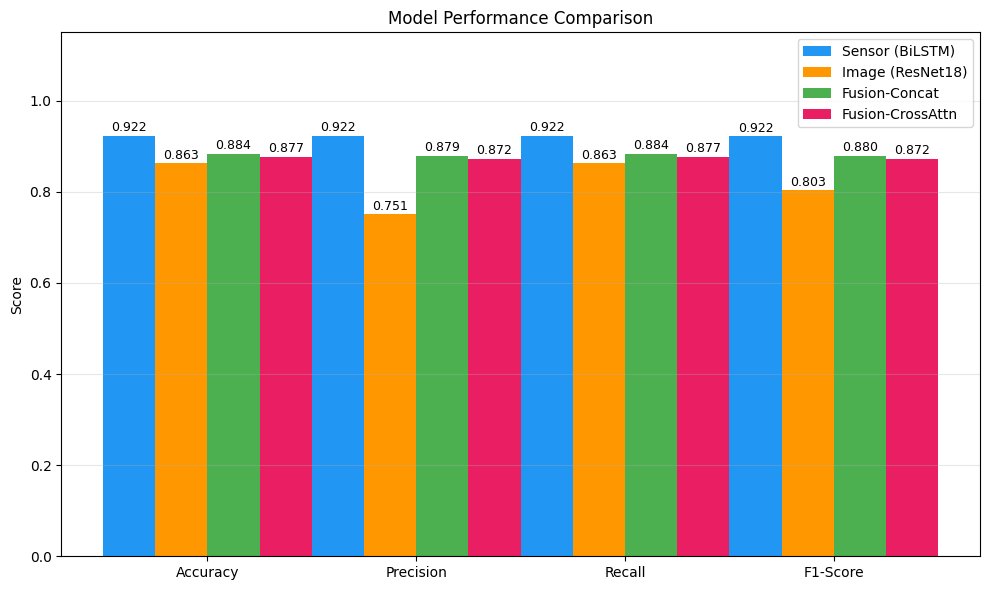

In [23]:
# 결과 수집
all_results = {"Sensor (BiLSTM)": sensor_result}
all_histories = {"Sensor (BiLSTM)": sensor_history}
if image_result:
    all_results["Image (ResNet18)"] = image_result
    all_histories["Image (ResNet18)"] = image_history
if fusion_result:
    all_results["Fusion-Concat"] = fusion_result
    all_histories["Fusion-Concat"] = fusion_history
if fusion_attn_result:
    all_results["Fusion-CrossAttn"] = fusion_attn_result
    all_histories["Fusion-CrossAttn"] = fusion_attn_history

# 성능 비교 바 차트
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.25
colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]

for i, (name, res) in enumerate(all_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i % len(colors)])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                f"{v:.3f}", ha="center", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x + width * (len(all_results)-1)/2)
ax.set_xticklabels(metric_labels)
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

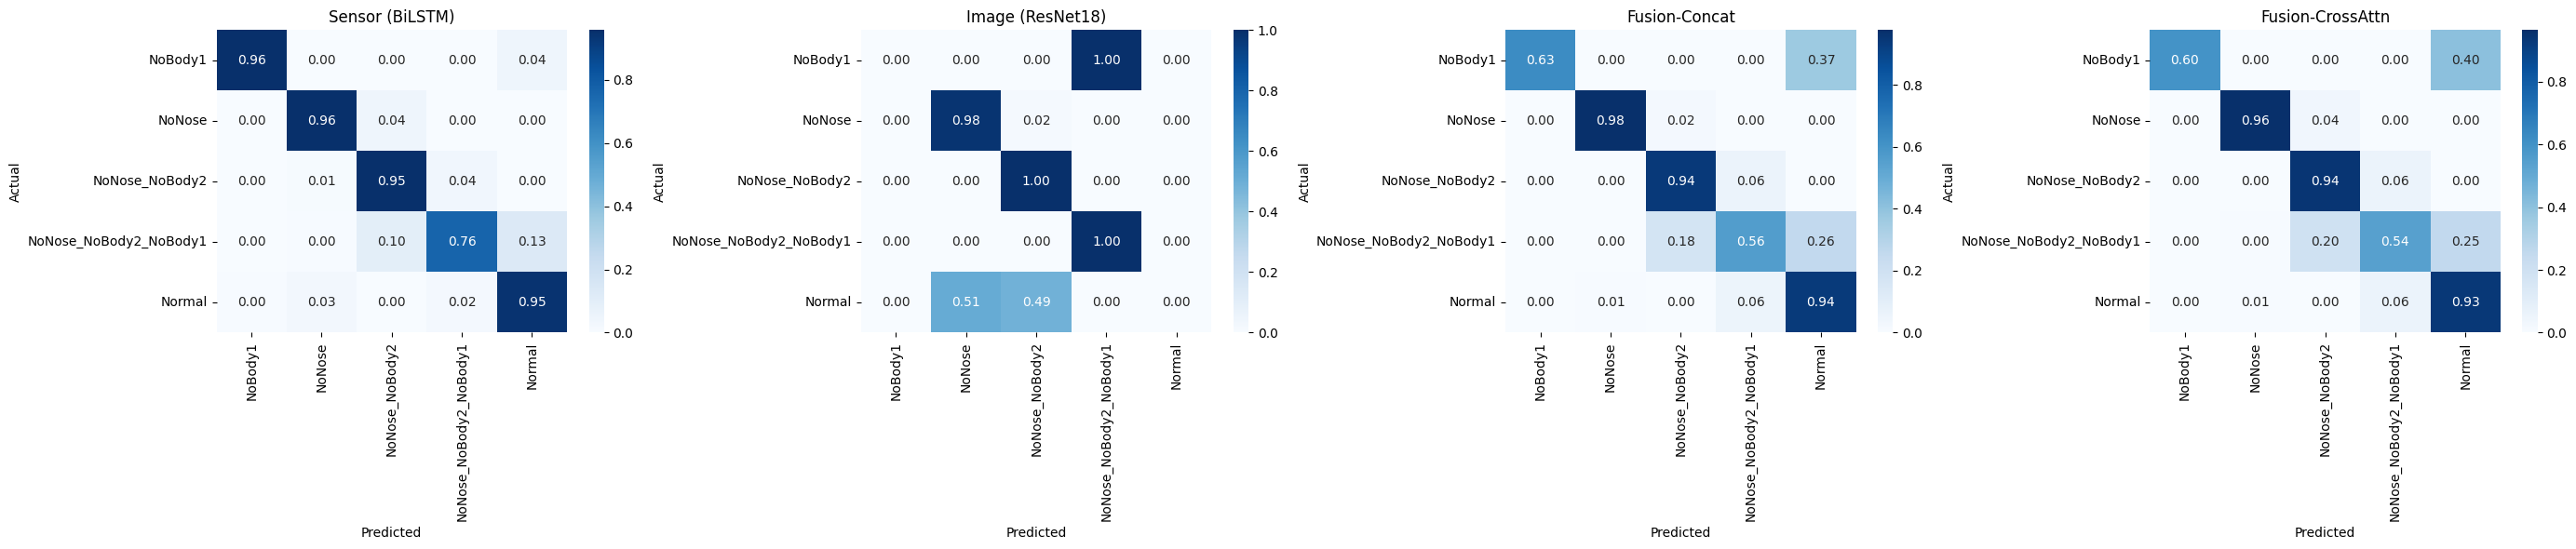

In [24]:
# Confusion Matrix
fig, axes = plt.subplots(1, len(all_results), figsize=(7*len(all_results), 6))
if len(all_results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, all_results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

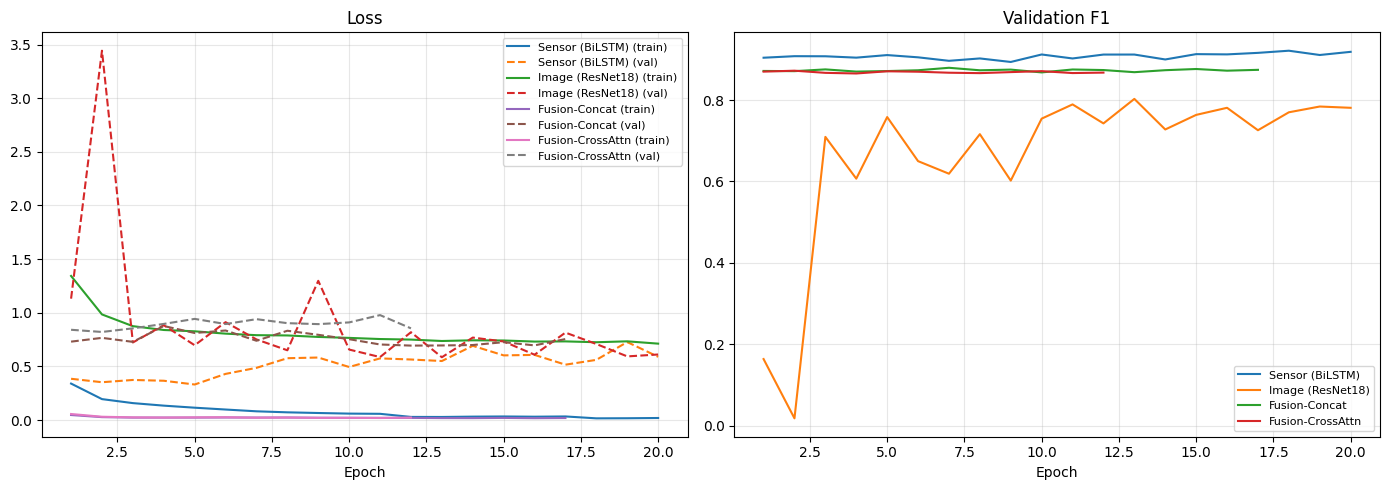

In [25]:
# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in all_histories.items():
    ep = range(1, len(hist["train_loss"])+1)
    axes[0].plot(ep, hist["train_loss"], label=f"{name} (train)")
    axes[0].plot(ep, hist["val_loss"], "--", label=f"{name} (val)")
    axes[1].plot(ep, hist["val_f1"], label=name)

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title("Validation F1"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# 최종 요약
print("\n" + "="*70)
print(" FINAL RESULTS SUMMARY")
print("="*70)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*70)
for name, res in all_results.items():
    print(f"{name:<25} {res['accuracy']:>10.4f} {res['precision']:>10.4f} "
          f"{res['recall']:>10.4f} {res['f1']:>10.4f}")
print("="*70)
print("\nDone!")


 FINAL RESULTS SUMMARY
Model                       Accuracy  Precision     Recall         F1
----------------------------------------------------------------------
Sensor (BiLSTM)               0.9224     0.9225     0.9224     0.9215
Image (ResNet18)              0.8630     0.7510     0.8630     0.8031
Fusion-Concat                 0.8838     0.8788     0.8838     0.8796
Fusion-CrossAttn              0.8770     0.8723     0.8770     0.8724

Done!
